# Bird Data and Air Pollution Correlation Analysis
This notebook investigates the relationship between bird occurrence counts (`individualCount`) and various air pollution metrics from the integrated dataset. All other environmental and climate variables have been excluded to focus solely on this interaction.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualizations
sns.set_theme(style="whitegrid")
%matplotlib inline

## Data Loading and Formatting
We load `final4.csv` and subset the data down to only the relevant columns.

In [7]:
# Read the dataset
df = pd.read_csv('final5.csv')

# Define the columns to keep
bird_col = ['individualCount']
pollution_cols = [
    'BCSMASS',   # Black Carbon Mass
    'DUEXTT25',  # Dust Extinction
    'DUSMASS',   # Dust Mass
    'OCSMASS',   # Organic Carbon Mass
    'SO2SMASS',  # Sulfur Dioxide Mass
    'SO4SMASS',  # Sulfate Mass
    'SSSMASS',   # Sea Salt Mass
    'TOTEXTTAU', # Total Aerosol Extinction
    'TOTSCATAU'  # Total Aerosol Scattering
]
time_loc_cols = ['eventDate', 'decimalLatitude', 'decimalLongitude', 'stateProvince']

# Create a focused dataframe
analysis_df = df[bird_col + pollution_cols + time_loc_cols].copy()

# Clean up any potential missing values and format dates
analysis_df = analysis_df.dropna()
analysis_df['eventDate'] = pd.to_datetime(analysis_df['eventDate'])

# Display the first few rows
display(analysis_df.head())

,individualCount,BCSMASS,DUEXTT25,DUSMASS,OCSMASS,SO2SMASS,SO4SMASS,SSSMASS,TOTEXTTAU,TOTSCATAU,eventDate,decimalLatitude,decimalLongitude,stateProvince
0,8.0,5.794512e-10,0.001600,1.548033e-09,2.780749e-09,1.643020e-10,3.372161e-09,3.725563e-08,0.175115,0.165737,2021-01-06,9.058512,79.855020,Mannar
1,31.0,3.096564e-10,0.021307,1.578878e-08,1.537093e-09,4.319662e-09,1.169898e-09,5.924096e-08,0.191869,0.184795,2024-09-24,6.927894,79.865005,Colombo
2,10.0,9.678071e-10,0.001877,2.117789e-09,4.676763e-09,4.725881e-09,4.424376e-09,3.249729e-08,0.198127,0.187366,2024-12-23,6.866285,79.931440,Colombo
3,1.0,2.822976e-10,0.020004,1.525811e-08,1.535989e-09,2.551352e-09,1.286736e-09,3.795434e-08,0.162928,0.156176,2024-09-13,7.401229,80.690730,Matale
4,6.0,8.410959e-10,0.001956,1.985992e-09,4.197754e-09,1.223400e-09,4.910509e-09,4.148581e-08,0.213164,0.203239,2024-11-28,8.154166,79.736084,Puttalam


## Correlation Heatmap
The correlation matrix helps identify any linear relationships between the air pollution parameters and the number of birds sighted. Values closer to 1 or -1 indicate string correlations, while values near 0 indicate weak or no correlations.

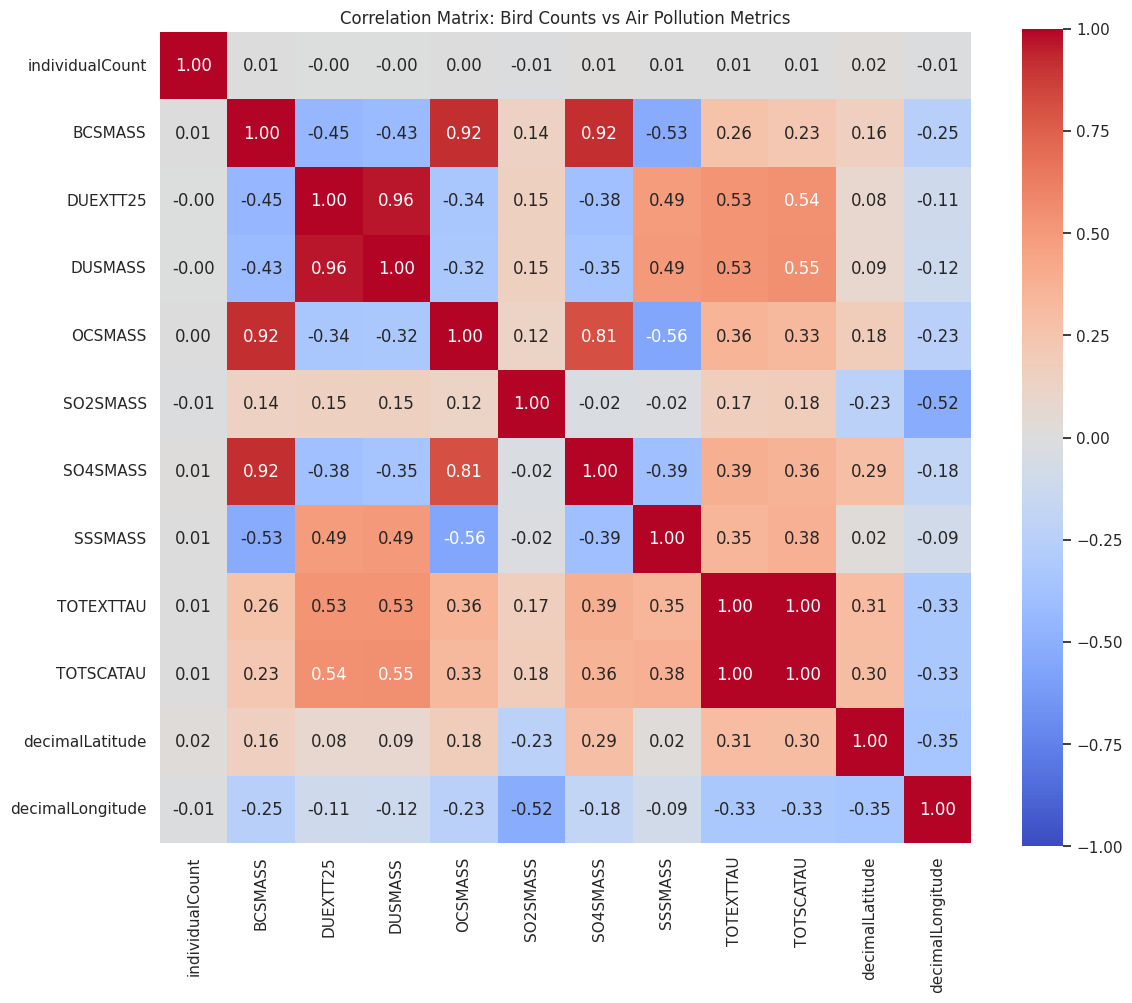

In [8]:
# Calculate the Pearson correlation matrix
corr_matrix = analysis_df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix: Bird Counts vs Air Pollution Metrics')
plt.tight_layout()
plt.show()

## Scatter Plots
Visualize the individual relationships between each pollutant and the bird `individualCount`.

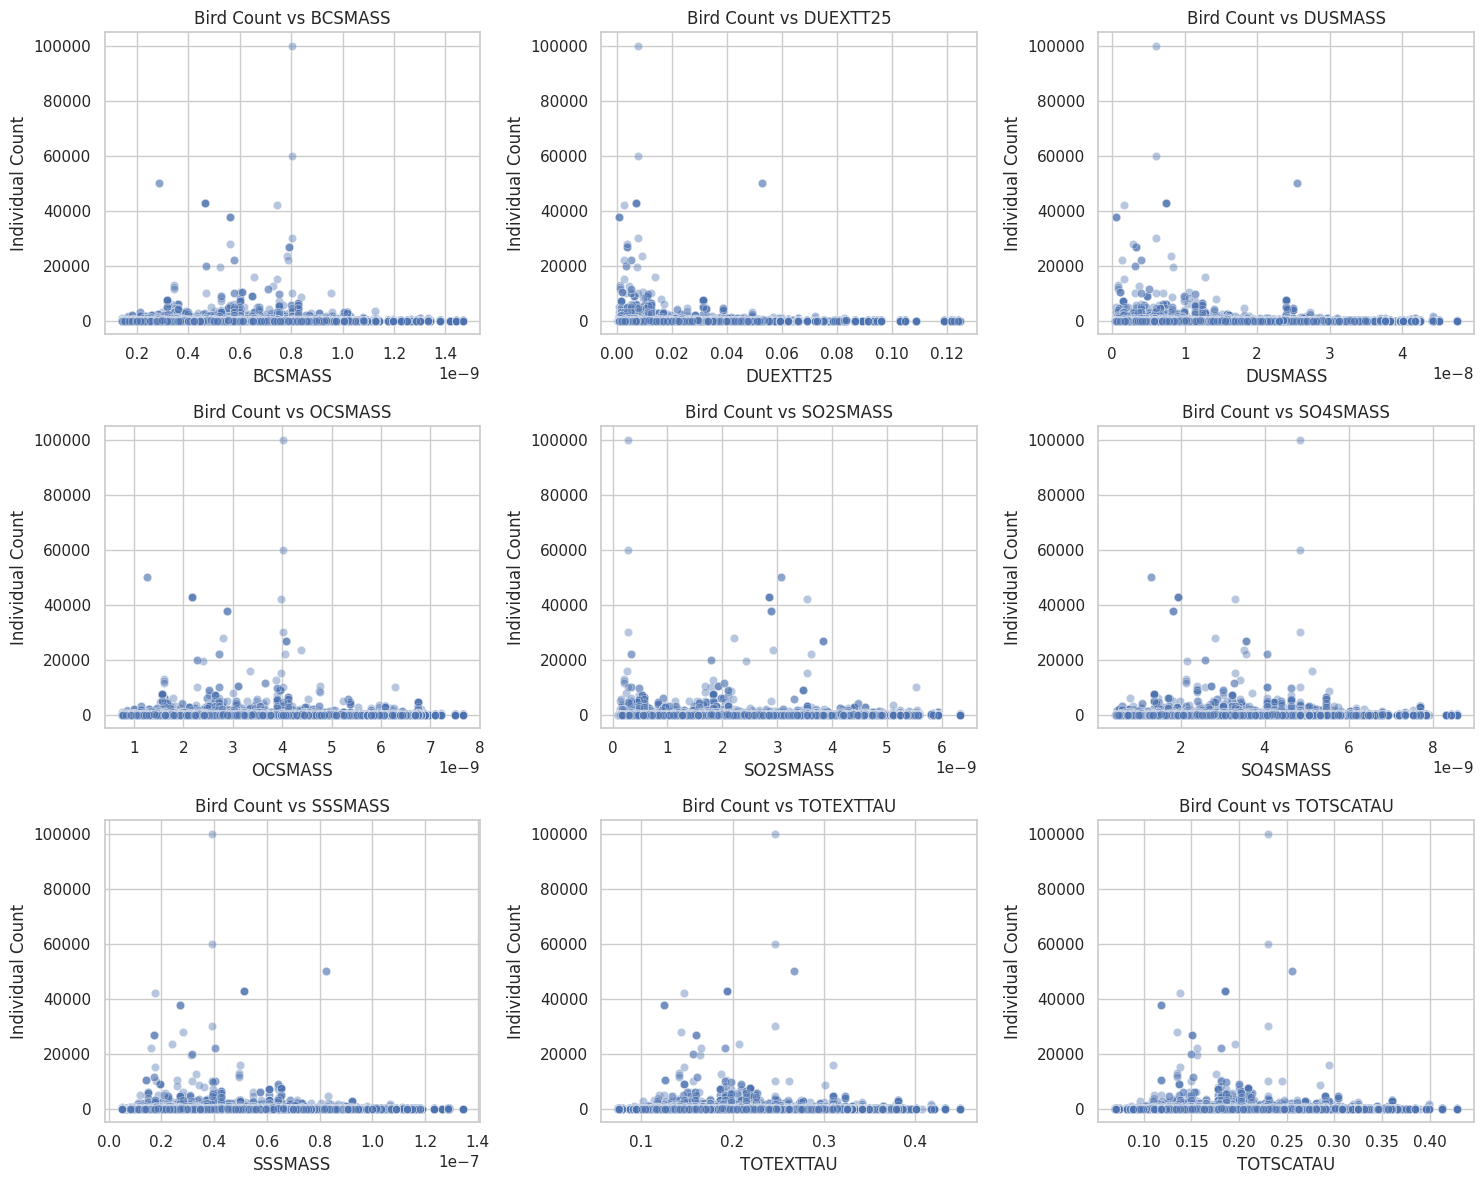

In [9]:
# Create a grid of scatter plots
plt.figure(figsize=(15, 12))

for i, col in enumerate(pollution_cols, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=analysis_df[col], y=analysis_df['individualCount'], alpha=0.4, color='b')
    plt.title(f'Bird Count vs {col}')
    plt.xlabel(col)
    plt.ylabel('Individual Count')

plt.tight_layout()
plt.show()

## Time Series Analysis
Let's aggregate the data by date to observe temporal trends. We compare how average birds sighted (`individualCount`) correlates day-by-day with the `TOTSCATAU` (Total Aerosol Scattering) and `TOTEXTTAU` (Total Extinction), which serve as proxies for general air pollution.

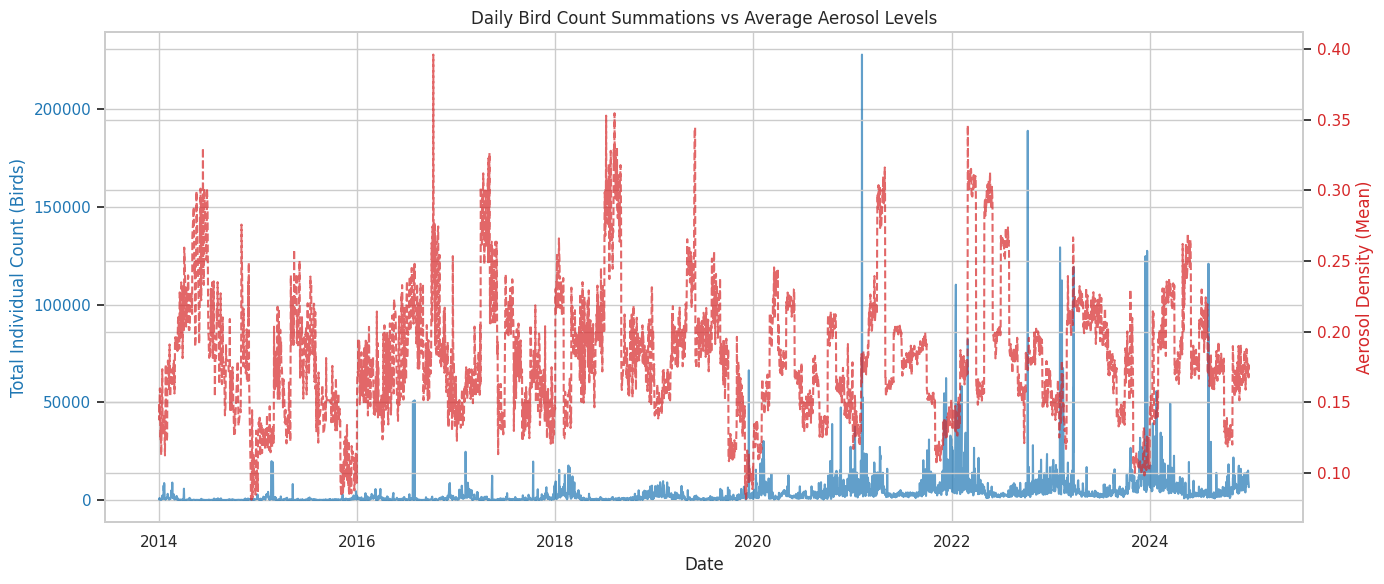

In [10]:
# Group by eventDate to find the daily average pollution vs total bird combinations
daily_agg = analysis_df.groupby('eventDate').agg({
    'individualCount': 'sum',
    'TOTSCATAU': 'mean',
    'TOTEXTTAU': 'mean'
}).reset_index()

# Plot temporal trends for bird counts and pollution metrics
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot total birds
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Individual Count (Birds)', color='tab:blue')
ax1.plot(daily_agg['eventDate'], daily_agg['individualCount'], color='tab:blue', alpha=0.7, label='Bird Count')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot average air pollution on alternative axis
ax2 = ax1.twinx()  
ax2.set_ylabel('Aerosol Density (Mean)', color='tab:red')
ax2.plot(daily_agg['eventDate'], daily_agg['TOTSCATAU'], color='tab:red', alpha=0.7, linestyle='--', label='TOTSCATAU')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Daily Bird Count Summations vs Average Aerosol Levels')
fig.tight_layout()
plt.show()

## Location Scatter Plot Analysis
Now let's map the locations where the data was collected, to discover geographic clusters with high or low pollution and observe relative bird population sizes.

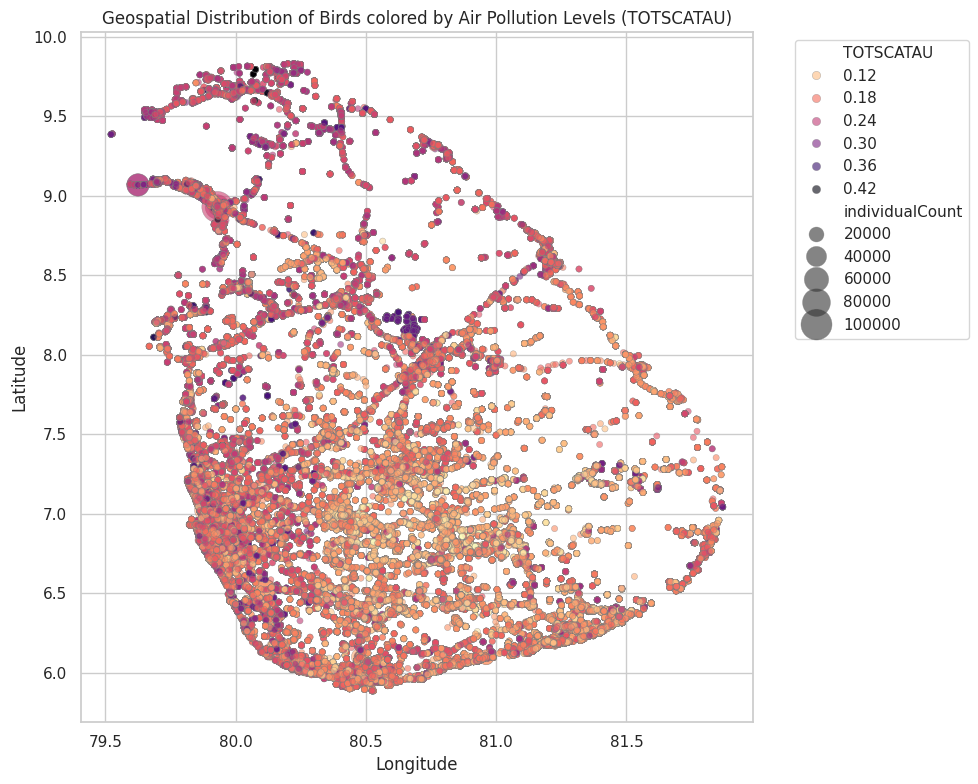

In [11]:
# We will plot the latitude/longitude scatter and scale point size by pollution/bird metrics
plt.figure(figsize=(10, 8))

# Map birds using a scatterplot, where color hue marks pollution level and size marks count length
sns.scatterplot(
    data=analysis_df,
    x='decimalLongitude',
    y='decimalLatitude',
    hue='TOTSCATAU',    # Color code by Total Aerosol Scattering (pollutant proxy)
    size='individualCount',  # Bubble size implies number of Birds
    sizes=(20, 500), 
    palette='magma_r',
    alpha=0.6,
    edgecolor='gray'
)

plt.title('Geospatial Distribution of Birds colored by Air Pollution Levels (TOTSCATAU)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## 1. Deep Dive: Per-Species Correlation
Overall linear correlations are low (near 0). However, lumping all bird species together might mask specific trends since urban-adapted birds could thrive in pollution while sensitive birds decline. Let's look at the correlation for the top 5 most frequently recorded species.

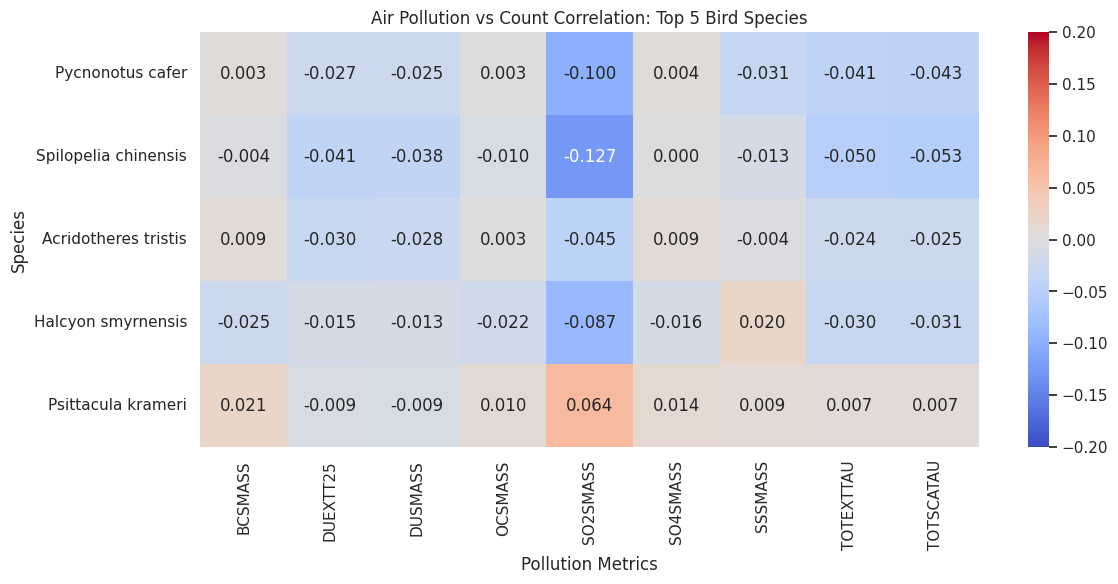

In [12]:
# Re-extract data from original dataframe to include scientific names
df_species = df[bird_col + pollution_cols + ['verbatimScientificName']].dropna()

# Find the top 5 most frequently recorded species
top_species = df_species['verbatimScientificName'].value_counts().nlargest(5).index

# Calculate correlations per species
species_corr = []
for species in top_species:
    species_data = df_species[df_species['verbatimScientificName'] == species]
    corrs = species_data.corr(numeric_only=True)['individualCount']
    corrs.name = species
    species_corr.append(corrs)

# Clean up into a dataframe for heatmap visualization
species_corr_df = pd.DataFrame(species_corr).drop(columns=['individualCount'])

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(species_corr_df, annot=True, cmap='coolwarm', fmt=".3f", vmin=-0.2, vmax=0.2)
plt.title('Air Pollution vs Count Correlation: Top 5 Bird Species')
plt.xlabel('Pollution Metrics')
plt.ylabel('Species')
plt.tight_layout()
plt.show()

## 2. Non-Linear Patterns: Threshold Analysis
Rather than looking just at linear relationships, what happens if we categorize the general pollution proxy (`TOTSCATAU`) into bins: "Low", "Medium", "High", and "Extreme"? We can visualize the distribution of bird sightings across these severity levels to see if extreme pollution events trigger different distributions of observations.

/tmp/ipykernel_9047/3520831090.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bins, x='Pollution_Severity', y='individualCount', palette='Set2')


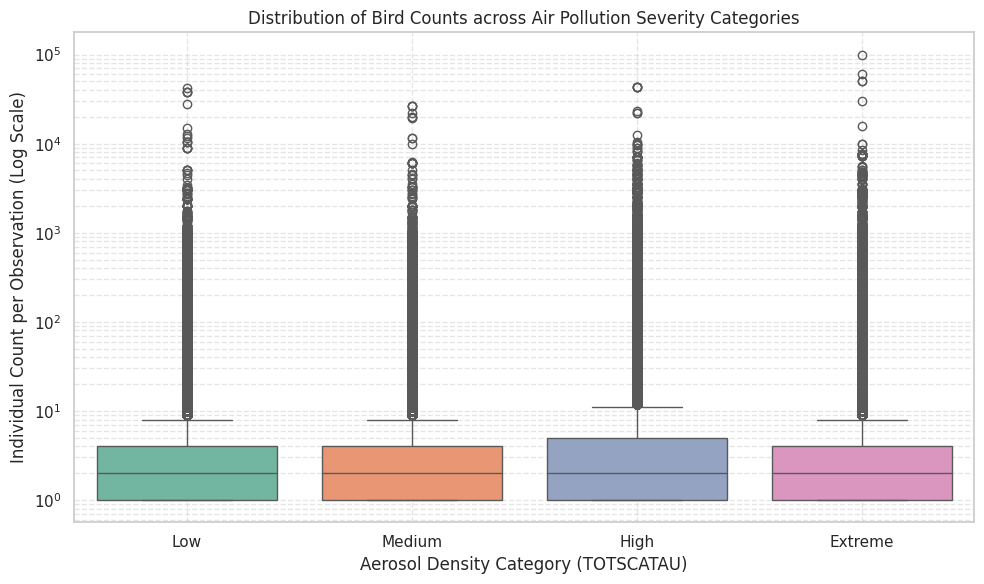

In [13]:
# Create quantiles for general air pollution (using Total Aerosol Scattering as proxy)
df_bins = analysis_df.copy()
# Create 4 relatively equal-sized groups representing severity levels
df_bins['Pollution_Severity'] = pd.qcut(df_bins['TOTSCATAU'], q=4, labels=['Low', 'Medium', 'High', 'Extreme'])

# Plot distribution of bird occurrences across these pollution severity levels
plt.figure(figsize=(10, 6))

# We use a log scale for Y because bird occurrence counts tend to be highly skewed (some flocks are massive)
sns.boxplot(data=df_bins, x='Pollution_Severity', y='individualCount', palette='Set2')
plt.yscale('log') # Use a logarithmic scale to compress massive outliers
plt.title('Distribution of Bird Counts across Air Pollution Severity Categories')
plt.xlabel('Aerosol Density Category (TOTSCATAU)')
plt.ylabel('Individual Count per Observation (Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
analysis_df[['individualCount'] + pollution_cols].corr(numeric_only=True)['individualCount'].sort_values(ascending=False)

individualCount    1.000000
SO4SMASS           0.011555
BCSMASS            0.007124
TOTEXTTAU          0.006793
TOTSCATAU          0.006442
SSSMASS            0.005609
OCSMASS            0.004482
DUSMASS           -0.001896
DUEXTT25          -0.002814
SO2SMASS          -0.008865
Name: individualCount, dtype: float64

In [19]:
bird_vs_pollution = (
    analysis_df[pollution_cols]
    .corrwith(analysis_df['individualCount'])
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

bird_vs_pollution

SO4SMASS     0.011555
SO2SMASS    -0.008865
BCSMASS      0.007124
TOTEXTTAU    0.006793
TOTSCATAU    0.006442
SSSMASS      0.005609
OCSMASS      0.004482
DUEXTT25    -0.002814
DUSMASS     -0.001896
dtype: float64